In [33]:
# import neccesary packages here
import numpy as np
from source import *

This Monte-Carlo program simulates populations of radio supernovae and supernova remnants based on VLBI observations of the ULIRG Arp 220 (Varenius+2019).

We can start with a single simulated population. The program function by sampling luminosities, source diameters, and source positions from the empirical functions observed in Arp 220. The total number of sources is estimated from the SNe rate. 

In [34]:
### Simulate the population
rate = 4 #SNe per year
pop = SNe_pop(rate)

For the luminosities, we assume a power-law luminosity function of the form:

$n(L) = AL_{24}^{\beta}$

where $n(L)$ is the number of supernovae/supernova remnants, $A$ is a scaling factor, $L_{24}$ is the 1.4 GHz luminosity in units of 1e24 erg/s/Hz, and $\beta$ is a negative number. You can specify the beta value (example A), or leave it blank to use the default value from the Arp 220 results ($\beta=-2.19$; example B)

Text(0, 0.5, 'Count')

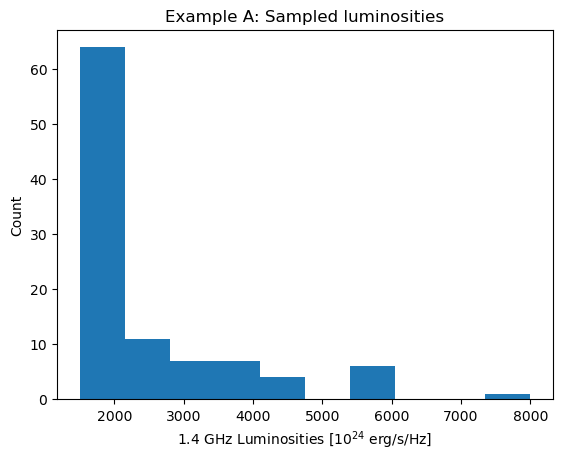

In [35]:
# Example A
lumin_range = np.arange(1.5e3, 2e4, 5e2)
pop.luminosities(lumin_range, beta=-3)

plt.hist(pop.lumin, bins=10)
plt.title('Example A: Sampled luminosities')
plt.xlabel('1.4 GHz Luminosities [$10^{24}$ erg/s/Hz]')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

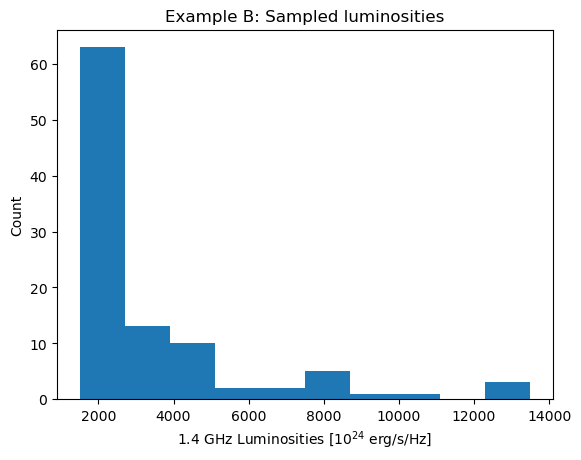

In [36]:
# Example B
pop.luminosities(lumin_range)

plt.hist(pop.lumin, bins=10)
plt.title('Example B: Sampled luminosities')
plt.xlabel('1.4 GHz Luminosities [$10^{24}$ erg/s/Hz]')
plt.ylabel('Count')

For the source diameters, we assume a power-law luminosity function of the form:

$D(L) = AL_{24}^{\alpha}$

where $D(L)$ is the source diameter, $A$ is a scaling factor, $L_{24}$ is the 1.4 GHz luminosity in units of 1e24 erg/s/Hz, and $\alpha$ is a negative number. The program samples from this function, then adds random Gaussian noise. Again, you can specify the parameters $A$ and $\alpha$ (example A), or leave it blank to use the default value from the Arp 220 results ($A\sim40, \alpha=-4/9$; example B). 

This function also has a MIN and MAX parameters, where you define the minimum and maximum source sizes. Here, we set the limits based on the Arp 220 results.

Text(0.5, 0, 'Diameters [pc]')

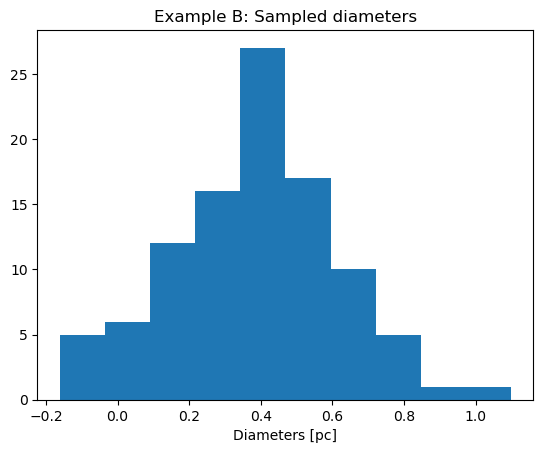

In [37]:
## Example A
pop.diameter(A=100, alpha=-5/7)

plt.hist(pop.diam, bins=10)
plt.title('Example B: Sampled diameters')
plt.xlabel('Diameters [pc]')

Text(0.5, 0, 'Diameters [pc]')

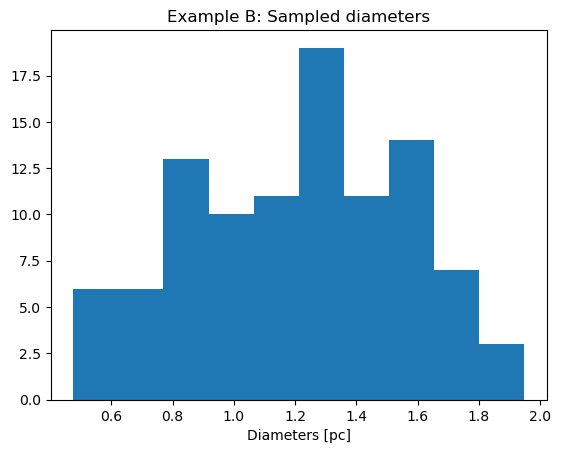

In [38]:
## Example B
pop.diameter(A=40, alpha=-4/9)

plt.hist(pop.diam, bins=10)
plt.title('Example B: Sampled diameters')
plt.xlabel('Diameters [pc]')

Finally, the spatial distribution of sources either assumes a (1) Gaussian distribution, (2) an exponential disk, or (3) a uniform distribution over an $N\timesN$ region in units of pixels. The program assumes that position $can$ overlap, given that this is a 2-dimensional projection of a 3 dimensional distribution. Note that for an exponential disk, one must input the scale height in units of pixels.

We again, show two different examples. First, a Gaussian (example A). Then, an exponential disk (example B). 

Text(0.5, 0, 'Position [pixels]')

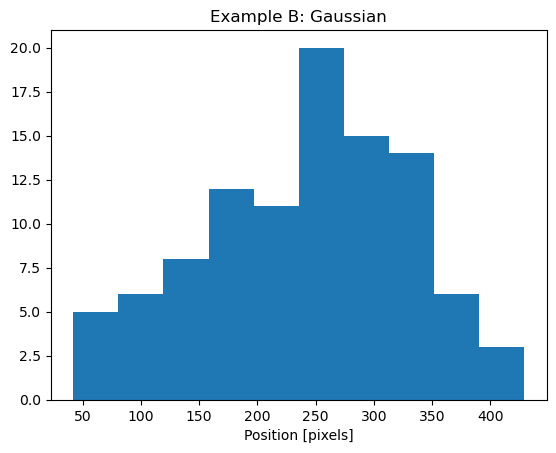

In [39]:
pop.position(N=500, dist = 'gauss')

plt.hist(pop.x, bins=10)
plt.title('Example B: Gaussian')
plt.xlabel('Position [pixels]')

Text(0.5, 0, 'Position [pixels]')

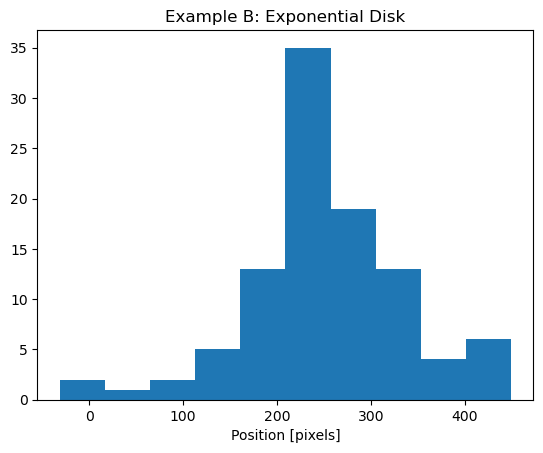

In [40]:
pop.position(N=500, scale_height=100, dist = 'exp')

plt.hist(pop.x, bins=10)
plt.title('Example B: Exponential Disk')
plt.xlabel('Position [pixels]')

Using this simulated population of SNe, we can now explore the range of luminosities that would be measured by an aperture of a given size. Let's say with an aperture of radius $\sim10$ parsecs, and I'm curious about how often I would measure a luminosity $>1 \times 10^{28}$ erg/s/Hz. 

We can set the parameter "criteria" to be this luminosity threshold (in units of 1e24 erg/s/Hz) and "radius_pc" to be the aperture radius in units of parsecs. Note that all the spatial parameters here are inputted in units of parsecs (the program will convert to pixels based on the inputted "FOV" (field of view) in parsecs). 

We set "visualize = True" to generate the image. This is also saved as a png in the directory. We recommend turning this off for multi-iteration runs. 

CPU times: user 3.31 s, sys: 899 ms, total: 4.21 s
Wall time: 4.21 s


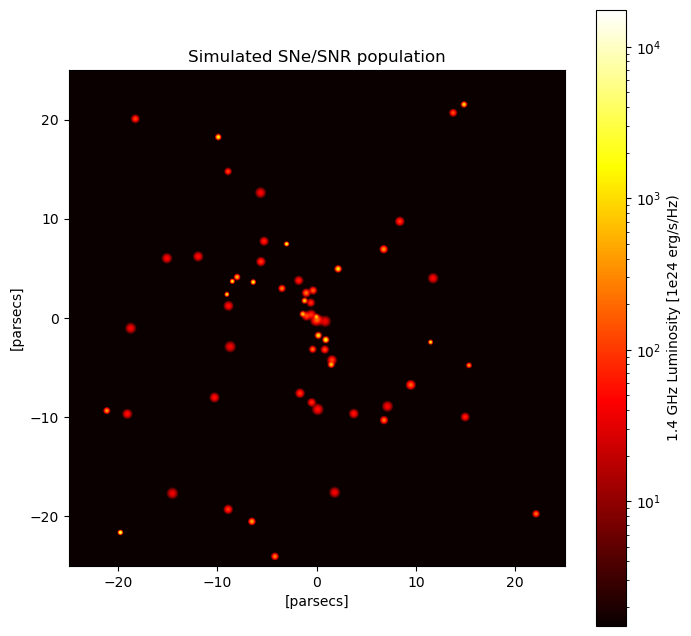

In [41]:
%%time 

## This takes about ~4 seconds on my computer
criteria=1e4 # equal to 1e28 erg/s/Hz
radius_pc = 10 #parsec

total_luminosities, count, bright_apertures, population = simulate_sne(rate=rate, radius_pc = radius_pc, lumin_range=lumin_range, criteria=criteria, FOV=200, 
             N=500, dist='exp', scale_height_pc=100, step_pc=10, visualize=True)

We can read out the total number of measurements with luminosities above the given threshold. This is returned as "bright_apertures" above, but note that some of the apertures overlap and may be redundant. Alternatively, the function also returns a value "count" that excludes by excluding overlapping measurements. These two values will be equal if step_pc = 2*radius_pc (the distance between aperture centers is equal to the diameter of the aperture).

In [42]:
print('Number of measurements above threshold:', bright_apertures)
print('Number of non-redundant measurements above threshold:', count)

Number of measurements above threshold: 361
Number of non-redundant measurements above threshold: 3


Text(0, 0.5, 'Count')

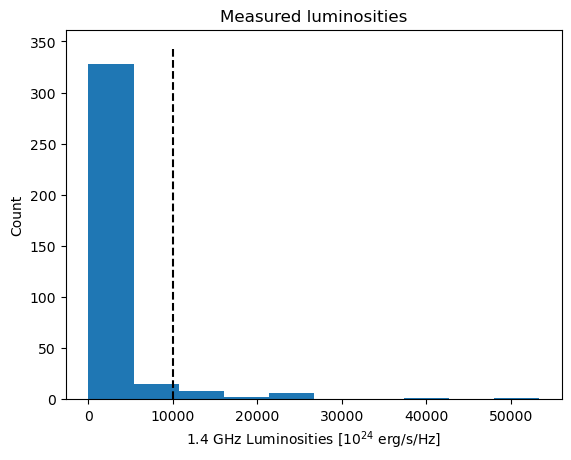

In [43]:
plt.hist(total_luminosities)

ymin, ymax = plt.ylim()
plt.title('Measured luminosities')
plt.vlines(ymin=0, ymax = ymax, x=criteria, linestyles = 'dashed', colors='k') #indicates threshold
plt.xlabel('1.4 GHz Luminosities [$10^{24}$ erg/s/Hz]')
plt.ylabel('Count')

We can now repeat this for multiple iterations to obtain statistics. This function is parallelized to improve the run times. We recommend "visualize = False" to avoid producing an excessive number of .png plots. Setting "savecsv=True" will also output a .csv file with the number of "counts" per iteration.

On my computer, this took 4.5 minutes for 500 iterations. 

In [44]:
%%time

iterations = 10
n_jobs = 16

total_luminosities, counts, apertures, population = run_mc(iterations, n_jobs, rate, radius_pc, lumin_range, criteria, FOV=200, 
                                                          N=500, dist='exp', scale_height_pc = 100, step_pc=10, 
                                                          visualize=False, savecsv=True)

CPU times: user 58.7 ms, sys: 10.4 ms, total: 69 ms
Wall time: 5.43 s


Error: iterable expected, not int

In [27]:
print('Number of non-redundant measurements above threshold:', np.median(counts), '+/-', f"{np.std(counts):.1f}")

Number of non-redundant measurements above threshold: 3.5 +/- 1.3


Text(0, 0.5, 'Count')

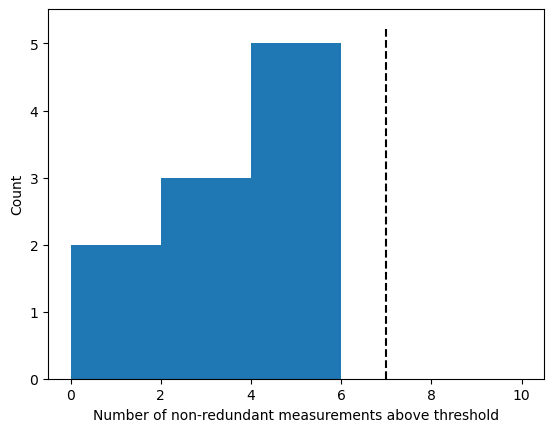

In [28]:
plt.hist(counts, bins=5,range=(0, 10))


ymin, ymax = plt.ylim()
plt.vlines(ymin=0, ymax = ymax, x=np.median(count), linestyles = 'dashed', colors='k') #Median count
plt.xlabel('Number of non-redundant measurements above threshold')
plt.ylabel('Count')

If you want to check the range of luminosities plotted for each individual iteration, the "population" class objects are saved. For example, here is the set of luminosities for the SNe/SNRs simulated in the first iteration:

In [ ]:
plt.hist(population[0].lumin, bins=10)
plt.title('Iteration 1: Sampled luminosities')
plt.xlabel('1.4 GHz Luminosities [$10^{24}$ erg/s/Hz]')
plt.ylabel('Count')

In [29]:
counts

[3, 4, 3, 3, 5, 4, 4, 1, 1, 5]

In [30]:
import csv

In [31]:
with open('output.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    # Wrap each item in its own list to make it a row
    for count in counts:
        writer.writerow([count])